<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/Copy_of_copy_of_copy_of_gp__4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# @title
!pip install google_play_scraper

In [31]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
apps = {
    "Amazon": "com.amazon.mShop.android.shopping",
    "Shein": "com.zzkko",
    "AliExpress": "com.alibaba.aliexpresshd",
    "Noon": "com.noon.buyerapp",
    "Trendyol": "trendyol.com"
}


In [33]:
def label_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [34]:
all_reviews = []

for app_name, app_id in apps.items():
    print(f"Fetching reviews for {app_name}...")

    result, _ = reviews(
        app_id,
        lang="en",
        country="us",
        sort=Sort.NEWEST,
        count=3000
    )

    for r in result:
        all_reviews.append({
            "app_name": app_name,
            "review_text": r["content"],
            "rating": r["score"],
            "sentiment_label": label_sentiment(r["score"])
        })

Fetching reviews for Amazon...
Fetching reviews for Shein...
Fetching reviews for AliExpress...
Fetching reviews for Noon...
Fetching reviews for Trendyol...


In [35]:
df = pd.DataFrame(all_reviews)
df.head()


,app_name,review_text,rating,sentiment_label
0,Amazon,I love Amazon shopping,5,Positive
1,Amazon,"way down, non competes prices , long delivery ...",1,Negative
2,Amazon,Every time I open the app it suggests differen...,2,Negative
3,Amazon,bekomme am Tag hunderte push Benachrichtigunge...,1,Negative
4,Amazon,Amazon have always been understanding i'm bedb...,5,Positive


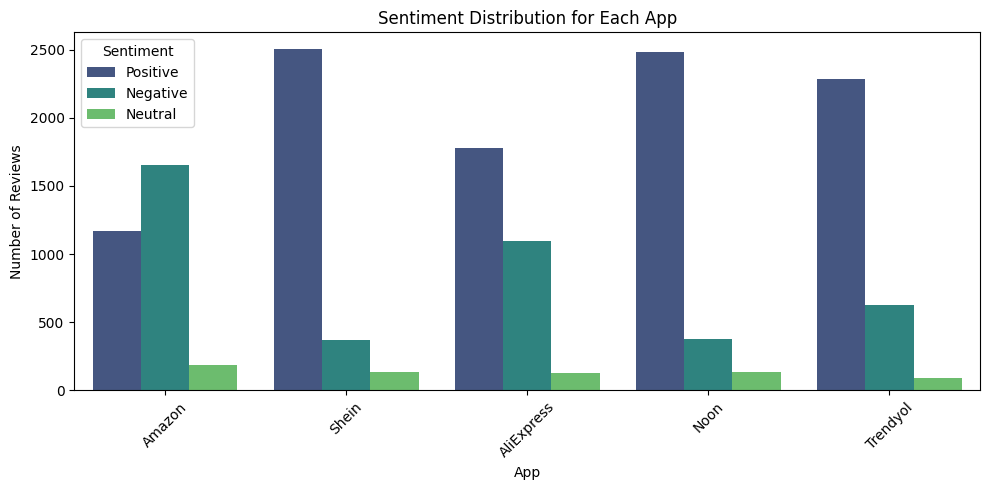

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [37]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    10212
Negative     4120
Neutral       668
Name: count, dtype: int64


In [38]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 14448


In [39]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [40]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [41]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,I love Amazon shopping,i love amazon shopping
1,"way down, non competes prices , long delivery ...",way down non competes prices long delivery ti...
2,Every time I open the app it suggests differen...,every time i open the app it suggests differen...
3,bekomme am Tag hunderte push Benachrichtigunge...,bekomme am tag hunderte push benachrichtigunge...
4,Amazon have always been understanding i'm bedb...,amazon have always been understanding im bedbo...
5,i cant stand how the customer service people c...,i cant stand how the customer service people c...
6,love it because I can get everything I need al...,love it because i can get everything i need al...
7,that allow companies to defraud their customers.,that allow companies to defraud their customers
8,better address entering options,better address entering options
9,Amazon customer service has only gotten worse....,amazon customer service has only gotten worse ...


In [42]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [43]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,i love amazon shopping,"[i, love, amazon, shopping]"
1,way down non competes prices long delivery ti...,"[way, down, non, competes, prices, long, deliv..."
2,every time i open the app it suggests differen...,"[every, time, i, open, the, app, it, suggests,..."
3,bekomme am tag hunderte push benachrichtigunge...,"[bekomme, am, tag, hunderte, push, benachricht..."
4,amazon have always been understanding im bedbo...,"[amazon, have, always, been, understanding, im..."


In [44]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

r
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[i, love, amazon, shopping]","[love, amazon, shopping]","[love, amazon, shopping]"
1,"[way, down, non, competes, prices, long, deliv...","[way, non, competes, prices, long, delivery, t...","[way, non, competes, price, long, delivery, ti..."
2,"[every, time, i, open, the, app, it, suggests,...","[every, time, open, app, suggests, different, ...","[every, time, open, app, suggests, different, ..."
3,"[bekomme, am, tag, hunderte, push, benachricht...","[bekomme, tag, hunderte, push, benachrichtigun...","[bekomme, tag, hunderte, push, benachrichtigun..."
4,"[amazon, have, always, been, understanding, im...","[amazon, always, understanding, im, bedbound, ...","[amazon, always, understanding, im, bedbound, ..."


In [45]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

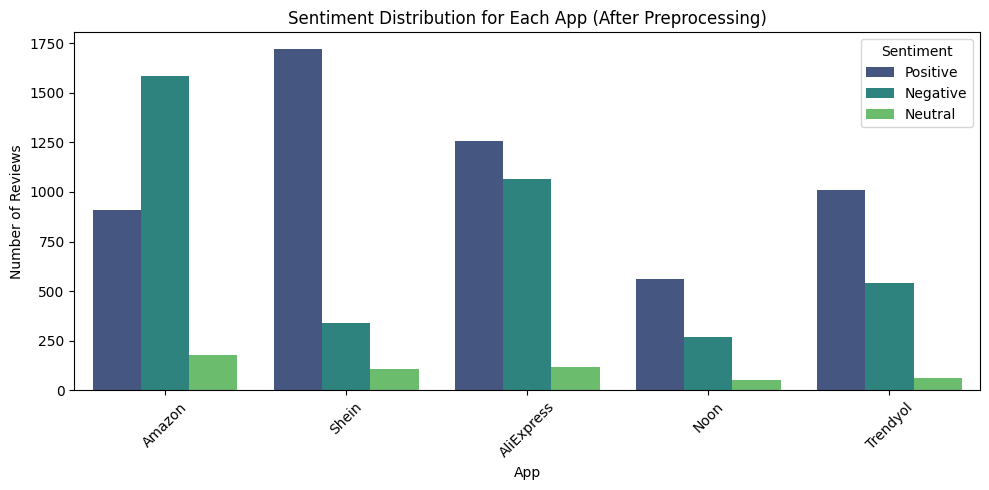

In [46]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [47]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Positive    5457
Negative    3797
Neutral      515
Name: count, dtype: int64


In [48]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [49]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    4365
Negative    3038
Neutral      412
Name: count, dtype: int64
After SMOTE: sentiment_label
Negative    4365
Positive    4365
Neutral     4365
Name: count, dtype: int64


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 0.8085977482088025
Classification Report:
               precision    recall  f1-score   support

    Negative       0.78      0.82      0.80       759
     Neutral       0.21      0.12      0.15       103
    Positive       0.86      0.87      0.86      1092

    accuracy                           0.81      1954
   macro avg       0.62      0.60      0.60      1954
weighted avg       0.80      0.81      0.80      1954

Confusion Matrix:
 [[622  21 116]
 [ 53  12  38]
 [121  25 946]]


In [53]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.718014329580348

Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.67      0.70       759
     Neutral       0.11      0.22      0.15       103
    Positive       0.83      0.80      0.81      1092

    accuracy                           0.72      1954
   macro avg       0.56      0.56      0.55      1954
weighted avg       0.75      0.72      0.73      1954

Confusion Matrix:
 [[506 100 153]
 [ 49  23  31]
 [140  78 874]]


In [54]:
# SUPPORT VECTOR MACHINE (SVM)

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_SVM)

print("SVM Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_SVM))


SVM Accuracy: 77.38 %

Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.79      0.80       759
     Neutral       0.12      0.30      0.18       103
    Positive       0.92      0.81      0.86      1092

    accuracy                           0.77      1954
   macro avg       0.62      0.63      0.61      1954
weighted avg       0.83      0.77      0.80      1954

Confusion Matrix:
 [[598 111  50]
 [ 45  31  27]
 [100 109 883]]


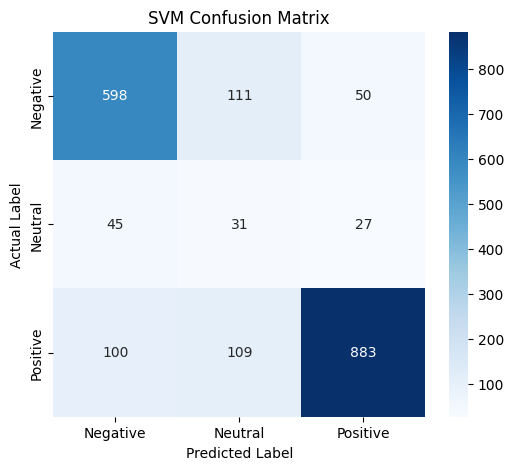

In [55]:

#  Confusion Matrix Graph FOR SVM

cm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [56]:
print(set(y_pred_SVM))

{'Negative', 'Positive', 'Neutral'}


In [57]:
from sklearn.naive_bayes import MultinomialNB


nb_model = MultinomialNB()


nb_model.fit(X_train_resampled, y_train_resampled)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7763561924257932

Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.78      0.79       759
     Neutral       0.13      0.32      0.18       103
    Positive       0.93      0.82      0.87      1092

    accuracy                           0.78      1954
   macro avg       0.62      0.64      0.61      1954
weighted avg       0.84      0.78      0.80      1954

Confusion Matrix:
 [[591 126  42]
 [ 46  33  24]
 [102  97 893]]


In [58]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:23:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8203684749232344

Classification Report:

              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       759
     Neutral       0.25      0.02      0.04       103
    Positive       0.83      0.92      0.87      1092

    accuracy                           0.82      1954
   macro avg       0.63      0.58      0.57      1954
weighted avg       0.79      0.82      0.80      1954

Confusion Matrix:

[[ 600    4  155]
 [  50    2   51]
 [  89    2 1001]]
